In [1]:
import math
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

## 生成多项式，原始特征，多项式特征，labels
$ y = 5 + 1.2x - 3.4\frac{x^2}{2!} + 5.6 \frac{x^3}{3!} + \epsilon \text{ where }
\epsilon \sim \mathcal{N}(0, 0.1^2) $

In [2]:
max_degree = 20
n_train, n_test = 100, 100
true_w = np.zeros(max_degree)
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])
features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
#广播机制，对200个元素直接计算0-19阶
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # gamma(n) = (n-1)!
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)
true_w = torch.tensor(true_w, dtype=torch.float32)
features = torch.tensor(features, dtype=torch.float32)
poly_features = torch.tensor(poly_features, dtype=torch.float32)
labels = torch.tensor(labels, dtype=torch.float32)
features[:2], poly_features[:2, :], labels[:2]

(tensor([[0.1137],
         [1.6562]]),
 tensor([[1.0000e+00, 1.1374e-01, 6.4685e-03, 2.4525e-04, 6.9737e-06, 1.5864e-07,
          3.0073e-09, 4.8865e-11, 6.9474e-13, 8.7801e-15, 9.9866e-17, 1.0326e-18,
          9.7877e-21, 8.5636e-23, 6.9574e-25, 5.2756e-27, 3.7503e-29, 2.5092e-31,
          1.5856e-33, 9.4918e-36],
         [1.0000e+00, 1.6562e+00, 1.3714e+00, 7.5710e-01, 3.1347e-01, 1.0383e-01,
          2.8660e-02, 6.7808e-03, 1.4037e-03, 2.5831e-04, 4.2781e-05, 6.4411e-06,
          8.8895e-07, 1.1325e-07, 1.3397e-08, 1.4792e-09, 1.5311e-10, 1.4916e-11,
          1.3724e-12, 1.1963e-13]]),
 tensor([5.1590, 6.5816]))

In [3]:
def load_array(data_arrays, batch_size, is_train=True):
    dataset = TensorDataset(*data_arrays)
    return DataLoader(dataset, batch_size=batch_size, shuffle=is_train)

net.eval()
将模型设置为评估（测试）模式。

作用：关闭模型内部在训练时才需要的特定层行为。例如，它会固定住批量规范化（Batch Normalization）的均值和方差，并让丢弃法（Dropout）失效，确保预测结果的确定性。

In [4]:
def evaluate_loss(net, data_iter, loss_fn):
    """评估模型在给定数据集上的平均损失"""
    net.eval()
    total_loss = 0.0
    total_num = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            y = y.reshape(y_hat.shape)
            losses = loss_fn(y_hat, y)
            total_loss += losses.sum().item()
            total_num += losses.numel()
    net.train()
    return total_loss / total_num

## 训练函数

In [5]:
def train(train_features, test_features, train_labels, test_labels, num_epochs=400):
    loss_fn = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    # 不设置偏置，因为多项式特征中的第 0 列已经是常数项 1
    net = nn.Sequential(
        nn.Linear(input_shape, 1, bias=False)
    )
    batch_size = min(10, train_labels.shape[0])
    train_iter = load_array(
        (train_features, train_labels.reshape(-1, 1)),
        batch_size,
        is_train=True
    )
    test_iter = load_array(
        (test_features, test_labels.reshape(-1, 1)),
        batch_size,
        is_train=False
    )
    optimizer = torch.optim.SGD(net.parameters(), lr=0.01)
    train_losses = []
    test_losses = []
    epochs = []
    for epoch in range(num_epochs):
        for X, y in train_iter:
            y_hat = net(X)
            y = y.reshape(y_hat.shape)
            loss = loss_fn(y_hat, y).mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if epoch == 0 or (epoch + 1) % 20 == 0:
            train_loss = evaluate_loss(net, train_iter, loss_fn)
            test_loss = evaluate_loss(net, test_iter, loss_fn)
            epochs.append(epoch + 1)
            train_losses.append(train_loss)
            test_losses.append(test_loss)
    print('weight:', net[0].weight.detach().numpy())
    plt.figure()
    plt.plot(epochs, train_losses, label='train')
    plt.plot(epochs, test_losses, label='test')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.yscale('log')
    plt.xlim(1, num_epochs)
    plt.ylim(1e-3, 1e2)
    plt.legend()
    plt.show()
    return net

## 三阶多项式，正常拟合

weight: [[ 5.0094495  1.2498105 -3.4026937  5.5175276]]


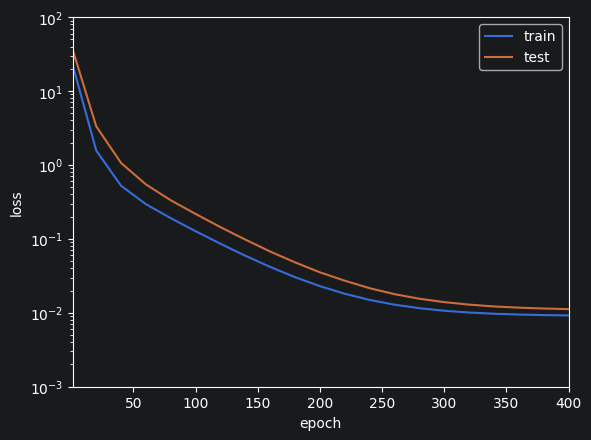

In [6]:
# 选择前 4 个维度：1, x, x^2 / 2!, x^3 / 3!
net_normal = train(
    poly_features[:n_train, :4],
    poly_features[n_train:, :4],
    labels[:n_train],
    labels[n_train:]
)

## 线性函数拟合，欠拟合

weight: [[3.6970341 3.489707 ]]


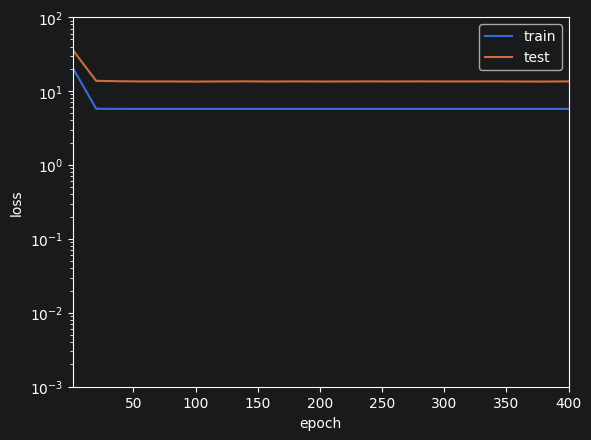

In [7]:
# 只选择前 2 个维度：1 和 x
net_underfit = train(
    poly_features[:n_train, :2],
    poly_features[n_train:, :2],
    labels[:n_train],
    labels[n_train:]
)

## 高阶多项式拟合，过拟合

weight: [[ 4.9797935e+00  1.2964001e+00 -3.2334414e+00  5.1781588e+00
  -4.6422702e-01  1.2697754e+00 -1.3609573e-02  7.7889554e-02
  -2.5013499e-02  2.0245535e-02 -1.4147924e-01 -2.7306206e-03
   8.7199047e-02  1.9839454e-01 -6.7815650e-03 -1.9265905e-02
   1.8274209e-01 -8.8960901e-02 -1.8065722e-01 -1.2266188e-01]]


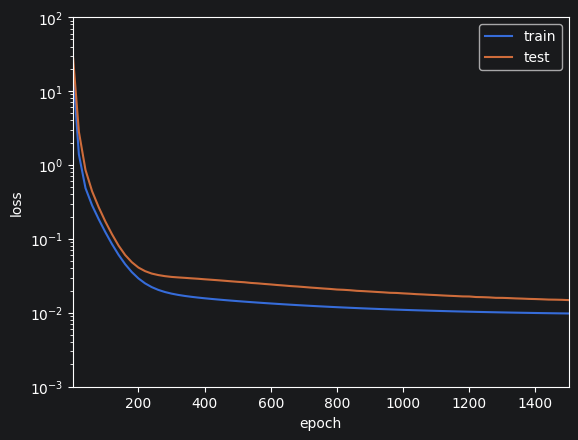

In [8]:
# 使用全部 20 个维度
net_overfit = train(
    poly_features[:n_train, :],
    poly_features[n_train:, :],
    labels[:n_train],
    labels[n_train:],
    num_epochs=1500
)